In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-e1ec21d6-0513-ed5d-3acd-fd72ecc6297f)


In [3]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    # 'epochs':50,
    # 'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [5]:
# @title Load data
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')


In [6]:
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)

brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
acronym_selec_list = list_dict['acronym_selec_list']

In [7]:
if len(brain_signal_lfp) == len(brain_region_index):
    print('Matched, no damage!')

Matched, no damage!


In [8]:
# acronym_interp = ['VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']

In [9]:
key = 'stimOff_times'

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Allen'

subject_od_ind = torch.load(model_dir + f'/subject_od_ind_Allen_{key}{0}.pt', weights_only=False)
subject_od_list = torch.load(model_dir + f'/subject_od_list_Allen_{key}{0}.pt', weights_only=False)

train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

In [10]:
acronym_interp = ['CA1']

In [18]:
sample_num = 128
spectrogram_acronym = {}
for acronym_ii, acronym in enumerate(acronym_list):
    if acronym in acronym_interp:

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        elif len(test_ind_acronym_ii) < sample_num:
            test_indiv = test_ind_acronym_ii

        elif len(test_ind_acronym_ii) >= sample_num:
            test_indiv = test_ind_acronym_ii[np.random.choice(len(test_ind_acronym_ii), sample_num, replace=False)]

        spectrogram = {}

        y_test = brain_region_index[test_indiv].to(device)
        x_test = lfp_spectro(brain_signal_lfp[test_indiv,:], spectro_args, train_args).requires_grad_()

        spectrogram_raw = x_test.detach().cpu().numpy().mean(axis=0)

        spectrogram['raw'] = spectrogram_raw[0, :, :]

        break



In [19]:
acronym

'CA1'

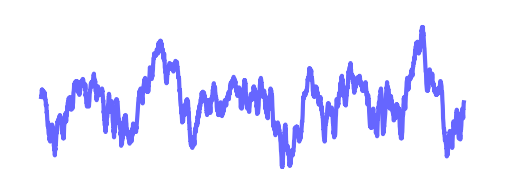

In [35]:
plt.figure(figsize=(3, 1), dpi=200)
plt.plot(brain_signal_lfp[test_indiv[3],:].detach().cpu().numpy(), color='blue', alpha=0.6)
plt.axis('off')
sns.despine()
plt.show()

In [14]:
x_test.size()

torch.Size([128, 1, 224, 28])

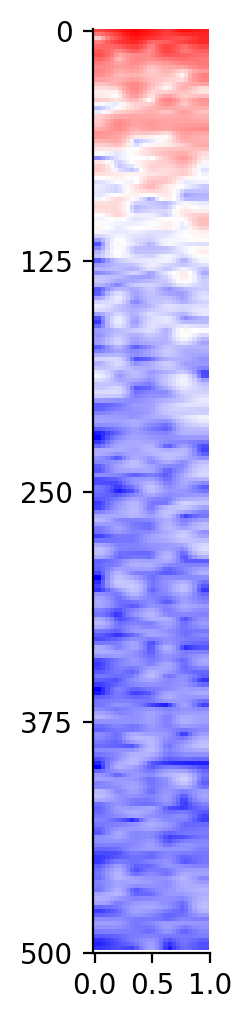

In [39]:
delta_show = 1e-5

plt.figure(figsize=(1, 6), dpi=200)
plt.imshow(np.log(x_test[3, 0, :, :].detach().cpu().numpy() + delta_show), cmap='bwr')
plt.yticks(np.linspace(0, 224, 5), np.int32((500 / 224) * np.linspace(0, 224, 5)))
plt.xticks(np.linspace(0, 28, 3), np.round((1 / 28) * np.linspace(0, 28, 3), 1))
# plt.xlabel('Time (s)')
# plt.ylabel('Frequence (Hz)')
# plt.colorbar(fraction=0.05)
sns.despine()
plt.show()